In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import ast

In [ ]:
df = pd.read_csv("./data/health_dataset.csv")


In [3]:
df

,hemoglobin,sugar,cholesterol,iron,vitamin_d,platelets,wbc_count,rbc_count,creatinine,uric_acid,findings
0,17.30,121.24,169.90,26.08,34.07,409852.84,8207.81,5.69,0.61,7.09,['LOW iron → Possible Iron Deficiency Anemia']
1,14.35,82.73,138.76,93.47,122.17,111184.68,4976.46,5.11,0.86,5.19,['HIGH vitamin D (Toxicity possible if persist...
2,14.30,106.00,205.60,126.83,41.94,169515.48,19690.72,5.83,0.81,3.86,"['HIGH cholesterol → Risk of Heart Disease', '..."
3,8.66,104.66,127.58,191.44,76.38,243513.32,7640.48,5.47,0.73,7.09,"['LOW hemoglobin → Possible Anemia', 'HIGH iro..."
4,21.54,111.85,194.14,69.73,43.72,163568.19,2776.97,5.08,1.18,4.82,"['HIGH hemoglobin → Possible Dehydration', 'LO..."
...,...,...,...,...,...,...,...,...,...,...,...
499995,17.47,104.57,202.16,145.10,37.37,271164.71,8114.97,5.81,0.97,6.37,['HIGH cholesterol → Risk of Heart Disease']
499996,14.21,129.00,147.71,127.18,116.97,308964.38,8521.85,6.60,0.85,4.20,['HIGH vitamin D (Toxicity possible if persist...
499997,15.79,111.14,190.02,56.62,98.15,363363.78,9420.13,5.00,1.12,6.91,['LOW iron → Possible Iron Deficiency Anemia']
499998,17.24,121.67,132.83,159.06,22.34,220974.97,6324.58,6.00,0.97,3.26,"['LOW vitamin D → Vitamin D Deficiency', 'LOW ..."


In [4]:
df.head(10)

,hemoglobin,sugar,cholesterol,iron,vitamin_d,platelets,wbc_count,rbc_count,creatinine,uric_acid,findings
0,17.30,121.24,169.90,26.08,34.07,409852.84,8207.81,5.69,0.61,7.09,['LOW iron → Possible Iron Deficiency Anemia']
1,14.35,82.73,138.76,93.47,122.17,111184.68,4976.46,5.11,0.86,5.19,['HIGH vitamin D (Toxicity possible if persist...
2,14.30,106.00,205.60,126.83,41.94,169515.48,19690.72,5.83,0.81,3.86,"['HIGH cholesterol → Risk of Heart Disease', '..."
3,8.66,104.66,127.58,191.44,76.38,243513.32,7640.48,5.47,0.73,7.09,"['LOW hemoglobin → Possible Anemia', 'HIGH iro..."
4,21.54,111.85,194.14,69.73,43.72,163568.19,2776.97,5.08,1.18,4.82,"['HIGH hemoglobin → Possible Dehydration', 'LO..."
5,15.67,79.86,185.16,68.20,99.08,381673.43,5391.01,4.71,2.50,6.20,['HIGH creatinine → Possible Kidney Issue']
6,13.80,95.09,113.87,128.56,53.16,169067.51,6176.88,5.16,2.39,6.78,['LOW cholesterol → May indicate malnutrition'...
7,13.98,119.93,182.06,121.74,83.97,298138.68,7659.13,5.30,0.62,1.08,['LOW Uric Acid → Nutrient imbalance']
8,10.75,168.17,155.78,143.11,46.02,173093.97,6028.26,4.93,1.25,6.49,"['LOW hemoglobin → Possible Anemia', 'HIGH blo..."
9,21.14,83.06,254.39,148.82,92.73,245401.04,4770.36,5.02,0.90,6.53,"['HIGH hemoglobin → Possible Dehydration', 'HI..."


In [5]:
df['findings'] = df['findings'].apply(ast.literal_eval)

In [6]:
X = df[['hemoglobin', 'sugar', 'cholesterol', 'iron', 'vitamin_d',
        'platelets', 'wbc_count', 'rbc_count', 'creatinine', 'uric_acid']]


In [7]:
X

,hemoglobin,sugar,cholesterol,iron,vitamin_d,platelets,wbc_count,rbc_count,creatinine,uric_acid
0,17.30,121.24,169.90,26.08,34.07,409852.84,8207.81,5.69,0.61,7.09
1,14.35,82.73,138.76,93.47,122.17,111184.68,4976.46,5.11,0.86,5.19
2,14.30,106.00,205.60,126.83,41.94,169515.48,19690.72,5.83,0.81,3.86
3,8.66,104.66,127.58,191.44,76.38,243513.32,7640.48,5.47,0.73,7.09
4,21.54,111.85,194.14,69.73,43.72,163568.19,2776.97,5.08,1.18,4.82
...,...,...,...,...,...,...,...,...,...,...
499995,17.47,104.57,202.16,145.10,37.37,271164.71,8114.97,5.81,0.97,6.37
499996,14.21,129.00,147.71,127.18,116.97,308964.38,8521.85,6.60,0.85,4.20
499997,15.79,111.14,190.02,56.62,98.15,363363.78,9420.13,5.00,1.12,6.91
499998,17.24,121.67,132.83,159.06,22.34,220974.97,6324.58,6.00,0.97,3.26


In [8]:
label_map = {
    "anemia": ["LOW hemoglobin", "LOW iron", "Borderline LOW hemoglobin", "LOW RBC"],
    "diabetes": ["HIGH blood sugar", "Borderline HIGH blood sugar"],
    "cholesterol_high": ["HIGH cholesterol", "Borderline HIGH cholesterol"],
    "cholesterol_low": ["LOW cholesterol"],
    "vitamin_d_deficiency": ["LOW vitamin D", "Borderline LOW vitamin D"],
    "vitamin_d_toxicity": ["HIGH vitamin D"],
    "kidney_issue": ["HIGH creatinine", "Borderline HIGH creatinine", "HIGH uric acid"],
    "low_creatinine": ["LOW creatinine"],
    "uric_acid_low": ["LOW Uric Acid"],
    "hypoglycemia": ["LOW blood sugar"],
    "polycythemia": ["HIGH RBC"],
    "dehydration": ["HIGH hemoglobin"],
    "iron_overload": ["HIGH iron"],
    "borderline_low_iron": ["Borderline LOW iron"],
    "wbc_low": ["LOW WBC"],
    "wbc_high": ["HIGH WBC"],
    "platelets_low": ["LOW Platelets"],
    "platelets_high": ["HIGH Platelets"]
}

# Function to convert findings to labels
def extract_labels(finding_list):
    result = {key: 0 for key in label_map}
    for finding in finding_list:
        for label, patterns in label_map.items():
            if any(p in finding for p in patterns):
                result[label] = 1
    return result



In [9]:
y = df['findings'].apply(extract_labels).apply(pd.Series)

In [10]:
y

,anemia,diabetes,cholesterol_high,cholesterol_low,vitamin_d_deficiency,vitamin_d_toxicity,kidney_issue,low_creatinine,uric_acid_low,hypoglycemia,polycythemia,dehydration,iron_overload,borderline_low_iron,wbc_low,wbc_high,platelets_low,platelets_high
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
499996,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
499997,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
499998,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0


In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
model = MultiOutputClassifier(RandomForestClassifier(random_state=42))
model.fit(X_train, y_train)


MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

In [13]:
y_pred = model.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.95131

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89     19037
           1       1.00      1.00      1.00      6192
           2       1.00      1.00      1.00      6042
           3       1.00      1.00      1.00      5919
           4       1.00      1.00      1.00      6028
           5       1.00      1.00      1.00      6050
           6       1.00      1.00      1.00      5960
           7       1.00      1.00      1.00      6017
           8       1.00      1.00      1.00      6023
           9       1.00      1.00      1.00      6023
          10       1.00      1.00      1.00      6070
          11       1.00      1.00      1.00      5997
          12       1.00      1.00      1.00      4078
          13       0.42      0.15      0.22      3986
          14       1.00      1.00      1.00      6012
          15       1.00      1.00      1.00      5865
          16       1.00      1.0

c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [18]:
import joblib


# Save the model
joblib.dump(model, "model/final_model.pkl")





['model/final_model.pkl']

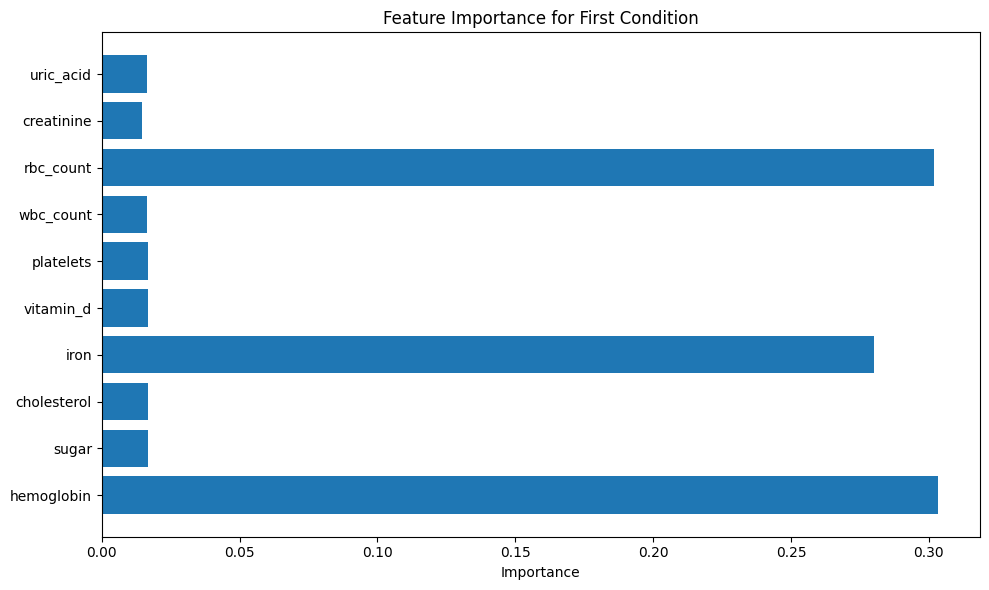

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importances from one of the estimators (e.g., first condition)
feature_importances = model.estimators_[0].feature_importances_
features = X.columns

# Plot
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances)
plt.xlabel("Importance")
plt.title("Feature Importance for First Condition")
plt.tight_layout()
plt.show()
